| Mode      | Ý nghĩa                               | Số kênh | Giá trị                     |
| --------- | ------------------------------------- | ------- | --------------------------- |
| `'1'`     | Ảnh nhị phân (đen/trắng)              | 1       | 0 hoặc 255                  |
| `'L'`     | Ảnh grayscale (ảnh xám)               | 1       | 0–255                       |
| `'P'`     | Ảnh palette (ảnh indexed color)       | 1       | 0–255, tham chiếu bảng màu  |
| `'RGB'`   | Ảnh màu True Color                    | 3       | (R, G, B) mỗi kênh 0–255    |
| `'RGBA'`  | Ảnh màu với alpha                     | 4       | (R, G, B, A) mỗi kênh 0–255 |
| `'CMYK'`  | Ảnh in (Cyan, Magenta, Yellow, Black) | 4       | 0–255                       |
| `'YCbCr'` | Ảnh dùng trong video                  | 3       | (Y, Cb, Cr)                 |
| `'I'`     | Ảnh 32-bit integer                    | 1       | integer                     |
| `'F'`     | Ảnh float                             | 1       | float                       |


(1536, 1024, 3)
(1536, 1024)
uint8


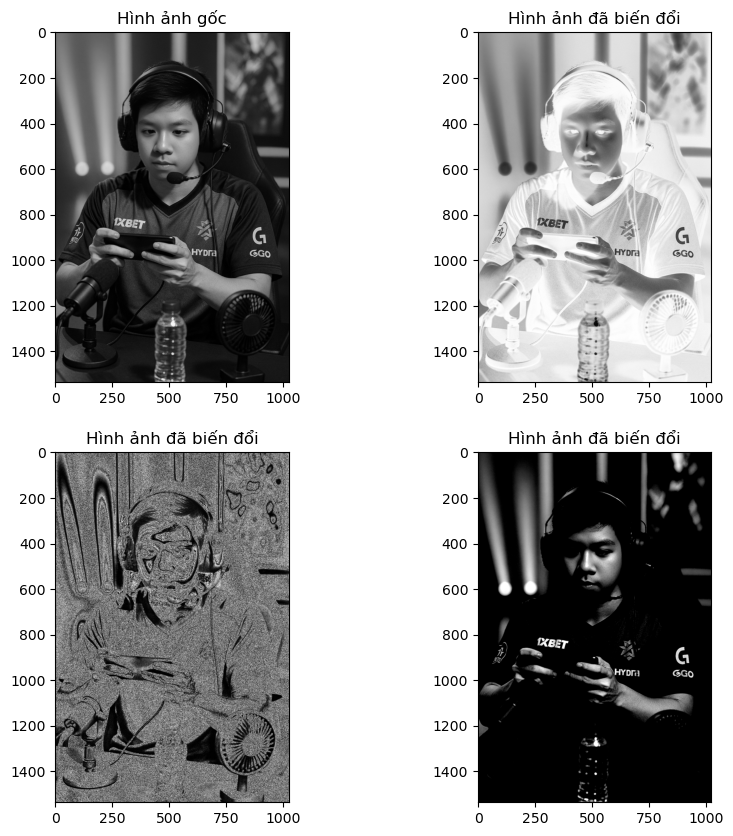

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Đường dẫn ảnh
my_path = 'e3a98f3b-7235-4367-8806-b87fb2e9531e.png'

# Đọc file hình ảnh
img = Image.open(my_path)

# Chuyển hình về array
img_array = np.array(img)

# Kiểm tra kích thước của hình ảnh
print(img_array.shape) # nếu ko có shape => in ra full mảng 3 chiều.

# Chuyển đổi sang hình ảnh xám
img_array_2 = np.array(img.convert('L')) # 'L' = Luminance (độ sáng) => chuyển ảnh sang ảnh grayscale (ảnh xám).
print(img_array_2.shape)
print(img_array_2.dtype)

# Biến đổi ảnh xám theo yêu cầu
inverted_image = 255 - img_array_2 # Invert ảnh bằng cách lấy 255 - giá trị pixel
  #plt.imshow(img_array_2, cmap='gray')

  # plt.imshow(inverted_image, cmap='gray')

# Bình phương giá trị pixel
squared_image = img_array_2 ** 2
  #plt.imshow(squared_image, cmap='gray')


# Giới hạn giá trị pixel trong khoảng 100-200
clamped_image = np.clip(img_array_2, 100,200)
  #plt.imshow(clamped_image, cmap='gray')


# Hiển thị hình ảnh gốc và hình ảnh biến đổi với khoảng trắng
fig, axs = plt.subplots(2, 2, figsize=(10,10))
fig.subplots_adjust(wspace=0.2, hspace=0.2)


axs[0, 0].imshow(img_array_2, cmap='gray') # cmap là colormap
axs[0, 0].set_title('Hình ảnh gốc')

axs[0, 1].imshow(inverted_image, cmap='gray')
axs[0, 1].set_title('Hình ảnh đã biến đổi')

axs[1, 0].imshow(squared_image, cmap='gray')
axs[1, 0].set_title('Hình ảnh đã biến đổi')

axs[1, 1].imshow(clamped_image, cmap='gray')
axs[1, 1].set_title('Hình ảnh đã biến đổi')
plt.show()

# CÁC GIÁ TRỊ KHÁC CỦA CMAP(COLORMAP)
1️⃣ Grayscale
### "gray" / "Greys" → đen–trắng

2️⃣ Sequential (theo thứ tự từ thấp → cao)
### "viridis" → xanh dương → xanh lá → vàng
### "plasma" → tím → đỏ → vàng
### "inferno" → đen → đỏ → vàng sáng
### "magma" → tím sẫm → vàng nhạt
### "cividis" → tối → sáng (thường dùng cho người mù màu)

3️⃣ Diverging (giữa hai cực màu)
### "coolwarm" → xanh → trắng → đỏ
### "bwr" → xanh → trắng → đỏ
### "seismic" → xanh → trắng → đỏ

4️⃣ Cyclic (dạng vòng, phù hợp dữ liệu góc)
### "hsv" → vòng màu cầu vồng
### "twilight" / "twilight_shifted"

5️⃣ Qualitative (màu rời rạc)
### "tab10", "tab20" → 10 hoặc 20 màu tách biệt
### "Pastel1", "Set1", "Set3" → bảng màu pastel

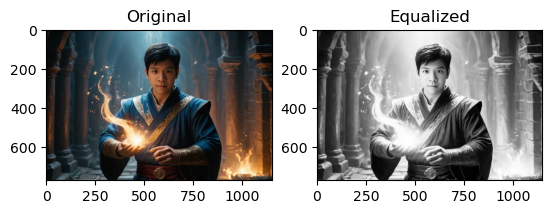

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def histogram_equalization(image, nbr_bins=256):
    # Đảm bảo hình ảnh đầu vào là ảnh xám
    if image.mode != 'L':
        image = image.convert('L')
    
    # Chuyển đổi hình ảnh thành mảng Numpy
    img_array = np.array(image)
    
    # Tính toán histogram của ảnh
    histogram, bins = np.histogram(img_array.flatten(), bins=nbr_bins, range=(0, 256), density=True)
    
    # Tính toán hàm phân phối tích lũy (CDF - Cumulative Distribution Function)
    cdf = histogram.cumsum()
    cdf = 255 * cdf / cdf[-1]  # chuẩn hóa về [0,255]
    
    # Lấy giá trị mới cho từng pixel dựa trên CDF
    img_equalized = np.interp(img_array.flatten(), bins[:-1], cdf)
    
    # Chuyển đổi mảng kết quả thành hình ảnh
    equalized_image = Image.fromarray(img_equalized.reshape(img_array.shape).astype('uint8'))
    
    return equalized_image

# Ví dụ sử dụng
img = Image.open("d0610e3ccc724172be3f6548ba435800.jpg")
eq_img = histogram_equalization(img)

# Hiển thị trước và sau
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap="gray")

plt.subplot(1,2,2)
plt.title("Equalized")
plt.imshow(eq_img, cmap="gray")

plt.show()

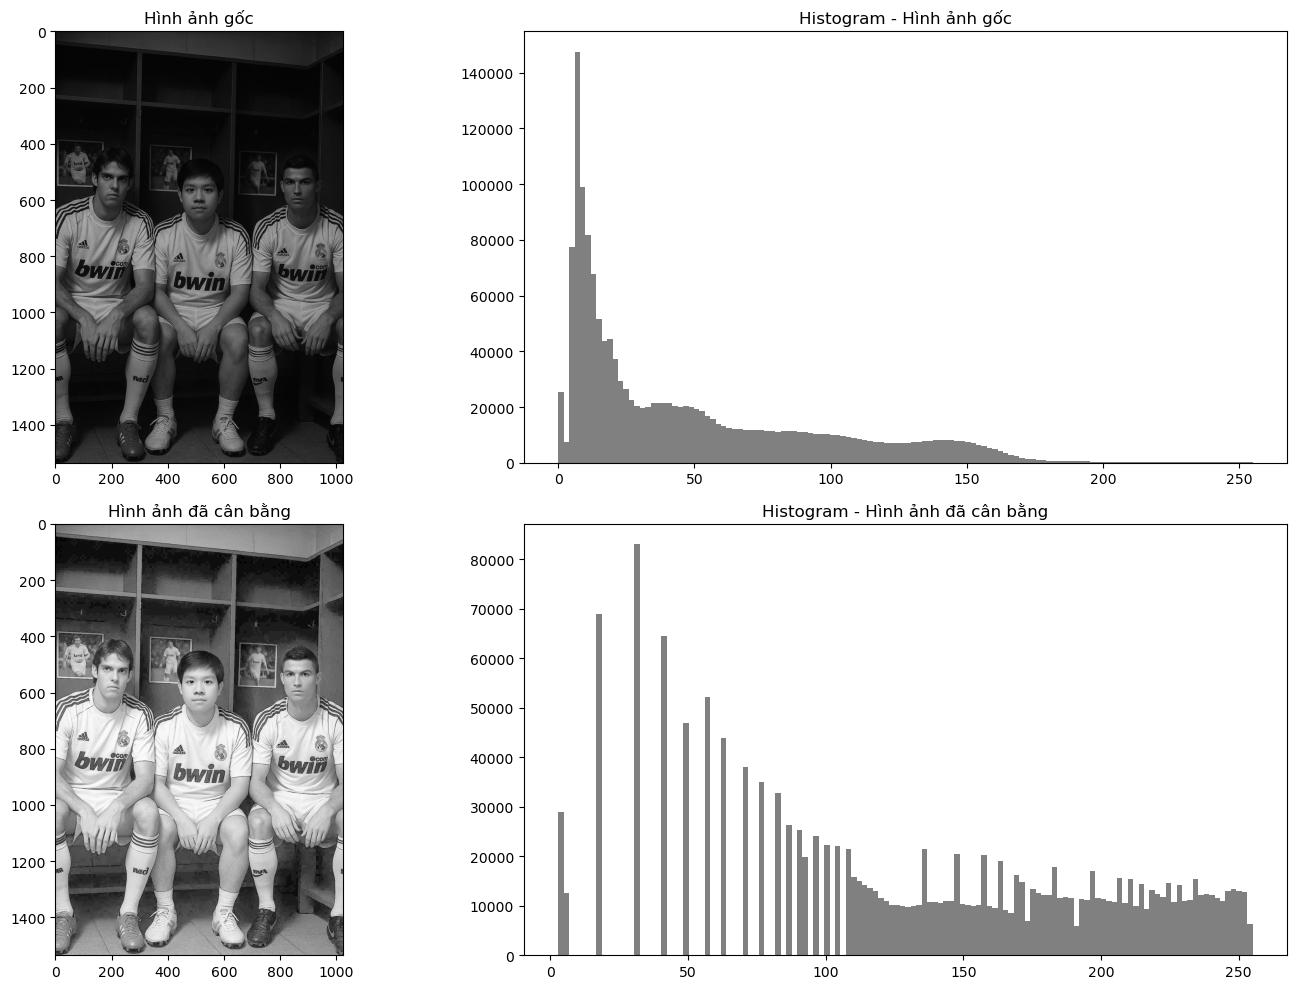

In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Hàm cân bằng histogram (đã fix ở phần trước)
def histogram_equalization(image, nbr_bins=256):
    if image.mode != 'L':
        image = image.convert('L')
    img_array = np.array(image)
    histogram, bins = np.histogram(img_array.flatten(), bins=nbr_bins, range=(0, 256), density=True)
    cdf = histogram.cumsum()
    cdf = 255 * cdf / cdf[-1]
    img_equalized = np.interp(img_array.flatten(), bins[:-1], cdf)
    equalized_image = Image.fromarray(img_equalized.reshape(img_array.shape).astype('uint8'))
    return equalized_image

# Đường dẫn ảnh
my_path = r'b5ca9580-b227-4775-8b0c-924d9eb5a213.png'

# Đọc file hình ảnh
img = Image.open(my_path)

# Áp dụng cân bằng histogram
equalized_image = histogram_equalization(img)

# Tạo một lưới 2x2 để hiển thị hình ảnh và histogram
plt.figure(figsize=(15, 10))

# Hình ảnh gốc
plt.subplot(2, 2, 1)
plt.imshow(img.convert('L'), cmap='gray')
plt.title('Hình ảnh gốc')

# Histogram ảnh gốc
plt.subplot(2, 2, 2)
plt.hist(np.array(img.convert('L')).flatten(), bins=128, color='gray')
plt.title('Histogram - Hình ảnh gốc')

# Hình ảnh sau cân bằng
plt.subplot(2, 2, 3)
plt.imshow(equalized_image, cmap='gray')
plt.title('Hình ảnh đã cân bằng')

# Histogram ảnh sau cân bằng
plt.subplot(2, 2, 4)
plt.hist(np.array(equalized_image).flatten(), bins=128, color='gray')
plt.title('Histogram - Hình ảnh đã cân bằng')

plt.tight_layout()
plt.show()
